# HR Employee Attrition Analysis

## Project Overview

The purpose of this project is to analyze the IBM HR Employee Attrition dataset using Python, NumPy, and Pandas.

The analysis focuses on understanding employee demographics, salary distribution, overtime, department performance, and factors that may influence employee attrition.

This project demonstrates practical data analysis skills including:

- Data Exploration
- Data Cleaning
- Statistical Analysis
- Grouping and Aggregation
- Business Insight Extraction

# Import Libraries

The required Python libraries are imported for data manipulation and numerical analysis.

In [176]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

The dataset is loaded into a Pandas DataFrame.

Initial inspection is performed to ensure that the data has been loaded correctly.

In [169]:
data = pd.read_csv('HR-Employee-Attrition.csv')

# Data Exploration

Before performing any analysis, it is important to understand the structure of the dataset.

In this section we inspect:

- Number of rows and columns
- Column names
- Data types
- Summary statistics
- Missing values

In [170]:
data.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [128]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [129]:
data.head(3).iloc[:,8:15]

,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel
0,1,1,2,Female,94,3,2
1,1,2,3,Male,61,2,2
2,1,4,4,Male,92,2,1


In [130]:
data.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')


# Data Cleaning

The dataset is examined for:

- Missing values
- Duplicate records
- Incorrect data types

Necessary cleaning operations are performed before analysis.

In [131]:
columns_to_keep=['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education','HourlyRate', 'JobRole',  'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager','MonthlyIncome' , 'OverTime']
columns_to_drop=['EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'JobInvolvement', 'JobLevel','JobSatisfaction',
       'MaritalStatus',  'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance']

In [132]:
len(columns_to_keep), len(columns_to_drop)

(15, 20)

In [133]:
newData=data[columns_to_keep]

In [134]:
newData.rename(columns={"DistanceFromHome":"DistanceHome"},inplace=True)

In [135]:
newData

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceHome,Education,HourlyRate,JobRole,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,MonthlyIncome,OverTime
0,41,Yes,Travel_Rarely,1102,Sales,1,2,94,Sales Executive,6,4,0,5,5993,Yes
1,49,No,Travel_Frequently,279,Research & Development,8,1,61,Research Scientist,10,7,1,7,5130,No
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,92,Laboratory Technician,0,0,0,0,2090,Yes
3,33,No,Travel_Frequently,1392,Research & Development,3,4,56,Research Scientist,8,7,3,0,2909,Yes
4,27,No,Travel_Rarely,591,Research & Development,2,1,40,Laboratory Technician,2,2,2,2,3468,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,41,Laboratory Technician,5,2,0,3,2571,No
1466,39,No,Travel_Rarely,613,Research & Development,6,1,42,Healthcare Representative,7,7,1,7,9991,No
1467,27,No,Travel_Rarely,155,Research & Development,4,3,87,Manufacturing Director,6,2,0,3,6142,Yes
1468,49,No,Travel_Frequently,1023,Sales,2,3,63,Sales Executive,9,6,0,8,5390,No


In [136]:
newData[newData["YearsAtCompany"]<=8].shape

(1022, 15)

In [137]:
newData.isna().sum()

Age                        0
Attrition                  0
BusinessTravel             0
DailyRate                  0
Department                 0
DistanceHome               0
Education                  0
HourlyRate                 0
JobRole                    0
YearsAtCompany             0
YearsInCurrentRole         0
YearsSinceLastPromotion    0
YearsWithCurrManager       0
MonthlyIncome              0
OverTime                   0
dtype: int64

# Statistical Analysis

Basic statistical measures are calculated using NumPy and Pandas.

These include:

- Mean
- Median
- Standard Deviation
- Percentiles
- Minimum
- Maximum

## Question 1

What is the average age of employees?

In [138]:
age=newData["Age"]
meanAge=np.mean(age)
AverageAge = np.around(meanAge)
AverageAge

np.float64(37.0)

### Insight

The average employee age is approximately 37 years.

In [139]:
sumAge=newData["Age"].sum()
age=newData["Age"].shape
age=age[0]
AverageAge=sumAge/age
AverageAge = np.around(AverageAge)
AverageAge

np.float64(37.0)

#### maximMaximum age

In [140]:
print(newData["Age"].max())
newData["Age"].min()

60


np.int64(18)

### median age

In [141]:
age=newData["Age"]
median=np.median(age)
median

np.float64(36.0)

### Avrage salary

In [ ]:
salary=newData["MonthlyIncome"]
standardStandardDeviation=np.std(salary)
AverageSalary = np.around(standardStandardDeviation)
AverageSalary

np.float64(4706.0)

### Employee salary quartiles

In [ ]:
Qsalary = np.quantile(salary, [0,0.25,0.5,0.75,1])
print(Qsalary)

[ 1009.  2911.  4919.  8379. 19999.]


##### Percentage of employees who resigned
& Percentage of employees who are still working
& Number of people who are working

In [ ]:
attrited=newData[newData["Attrition"]=="Yes"].shape
attrited=attrited[0]
total=newData["Attrition"].shape
total=total[0]
workers=total-attrited
print(workers)
percentageWorkers=(workers/total)*100
percentageAttrited=(attrited/total)*100
print(percentageWorkers)
print(percentageAttrited)
aritated=newData[newData["Attrition"]=="Yes"]
aritated["Age"].mean()

1233
83.87755102040816
16.122448979591837


np.float64(33.607594936708864)

# Exploratory Data Analysis (EDA)

The objective of this section is to answer business-related questions using the dataset.

The analysis investigates relationships between employee characteristics and attrition.

In [145]:
data.groupby("Department")["MonthlyIncome"].mean()

Department
Human Resources           6654.507937
Research & Development    6281.252862
Sales                     6959.172646
Name: MonthlyIncome, dtype: float64

In [146]:
data1=data.groupby("Department").size()
data1.idxmax()

'Research & Development'

#### 10 top high MonthlyIncome

In [147]:
newData.sort_values("MonthlyIncome", ascending=False)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceHome,Education,HourlyRate,JobRole,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,MonthlyIncome,OverTime
190,52,No,Travel_Rarely,699,Research & Development,1,4,65,Manager,33,18,11,9,19999,No
746,41,No,Non-Travel,247,Research & Development,7,1,55,Research Director,21,16,5,10,19973,No
851,56,No,Travel_Rarely,718,Research & Development,4,4,92,Manager,5,2,4,2,19943,No
165,50,No,Travel_Rarely,1452,Research & Development,11,3,53,Manager,5,4,4,4,19926,No
568,55,Yes,Travel_Rarely,725,Research & Development,2,3,78,Manager,5,2,1,4,19859,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1365,29,Yes,Travel_Frequently,746,Sales,24,3,45,Sales Representative,1,0,0,0,1091,No
1338,30,Yes,Travel_Rarely,945,Sales,9,3,89,Sales Representative,1,0,0,0,1081,No
764,28,No,Travel_Rarely,1144,Sales,10,1,74,Sales Representative,1,0,0,0,1052,No
727,18,No,Non-Travel,287,Research & Development,5,2,73,Research Scientist,0,0,0,0,1051,No


#### 10 of the youngest ages

In [148]:
newData.sort_values("Age", ascending=True).head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceHome,Education,HourlyRate,JobRole,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,MonthlyIncome,OverTime
727,18,No,Non-Travel,287,Research & Development,5,2,73,Research Scientist,0,0,0,0,1051,No
972,18,No,Non-Travel,1124,Research & Development,1,3,97,Laboratory Technician,0,0,0,0,1611,No
296,18,Yes,Travel_Rarely,230,Research & Development,3,3,54,Laboratory Technician,0,0,0,0,1420,No
1153,18,Yes,Travel_Frequently,544,Sales,3,2,70,Sales Representative,0,0,0,0,1569,Yes
828,18,Yes,Non-Travel,247,Research & Development,8,1,80,Laboratory Technician,0,0,0,0,1904,No
1311,18,No,Non-Travel,1431,Research & Development,14,3,33,Research Scientist,0,0,0,0,1514,No
301,18,No,Travel_Rarely,812,Sales,10,3,69,Sales Representative,0,0,0,0,1200,No
457,18,Yes,Travel_Frequently,1306,Sales,5,3,69,Sales Representative,0,0,0,0,1878,Yes
422,19,Yes,Travel_Rarely,489,Human Resources,2,2,52,Human Resources,1,0,0,0,2564,No
892,19,Yes,Non-Travel,504,Research & Development,10,3,96,Research Scientist,1,1,0,0,1859,Yes


#### 10 of employees who above 40 years old and quit

In [149]:
data=newData[(newData["Age"]>=40)&(newData["Attrition"]=="Yes")]
data.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceHome,Education,HourlyRate,JobRole,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,MonthlyIncome,OverTime
0,41,Yes,Travel_Rarely,1102,Sales,1,2,94,Sales Executive,6,4,0,5,5993,Yes
36,50,Yes,Travel_Rarely,869,Sales,3,2,86,Sales Representative,3,2,0,2,2683,Yes
45,41,Yes,Travel_Rarely,1360,Research & Development,12,3,49,Research Director,22,15,15,8,19545,No
50,48,Yes,Travel_Rarely,626,Research & Development,1,2,98,Laboratory Technician,1,0,0,0,5381,Yes
89,46,Yes,Travel_Rarely,669,Sales,9,2,64,Sales Executive,9,8,4,7,9619,No
122,56,Yes,Travel_Rarely,441,Research & Development,14,4,72,Research Scientist,5,4,4,3,4963,Yes
126,58,Yes,Travel_Rarely,147,Research & Development,23,4,94,Healthcare Representative,40,10,15,6,10312,No
136,51,Yes,Travel_Frequently,1150,Research & Development,8,4,53,Manufacturing Director,4,2,0,3,10650,No
182,41,Yes,Travel_Rarely,1356,Sales,20,2,70,Sales Representative,4,3,0,2,3140,Yes
271,47,Yes,Non-Travel,666,Research & Development,29,4,88,Manager,10,7,9,9,11849,Yes


#### Does overtime work affect resignation?

In [150]:
newData.groupby("OverTime")["Attrition"].value_counts()

OverTime  Attrition
No        No           944
          Yes          110
Yes       No           289
          Yes          127
Name: count, dtype: int64

In [151]:
pd.crosstab(data["OverTime"], data["Attrition"], normalize="index") * 100

Attrition,Yes
OverTime,
No,100.0
Yes,100.0


yes it effects.

#### Which departments have the most resignations?

In [152]:
data1=newData[newData["Attrition"]=="Yes"]
data1=data1.groupby("Department").size()
data1.idxmax()

'Research & Development'

'Research & Development' has the most.

### Distribution of Age

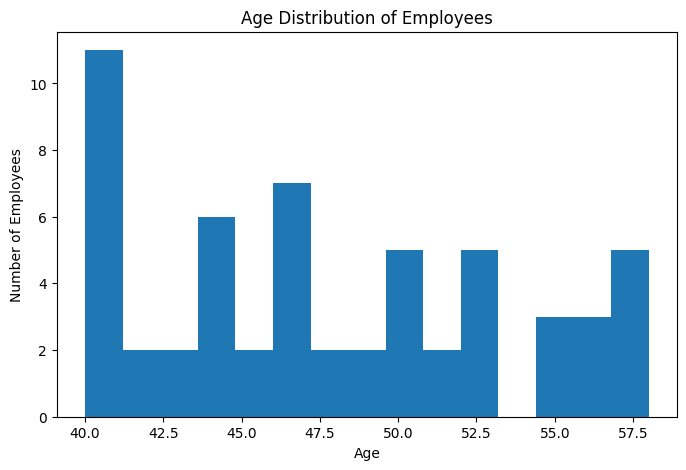

In [166]:

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

data["Age"].plot(kind="hist", bins=15)

plt.title("Age Distribution of Employees")
plt.xlabel("Age")
plt.ylabel("Number of Employees")

plt.show()

#### Monthly Income Distribution

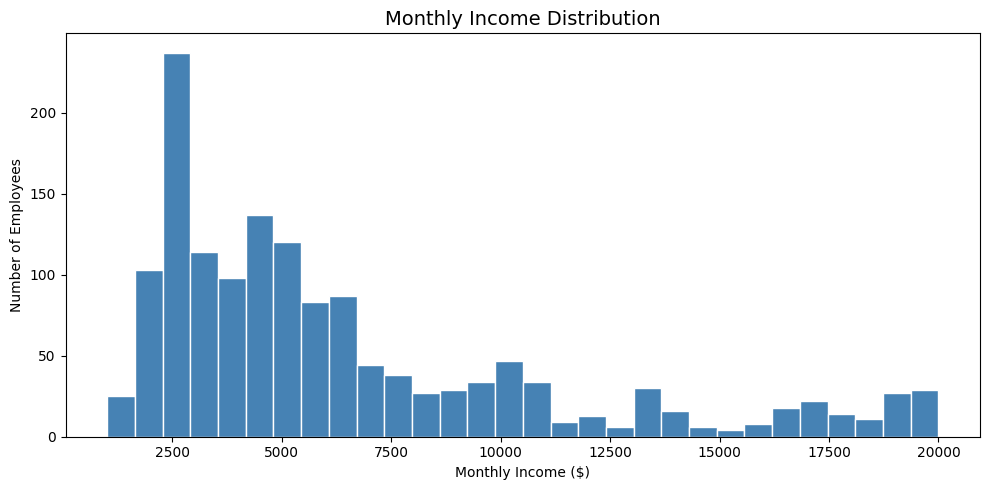

In [171]:
plt.figure(figsize=(10, 5))
plt.hist(newData["MonthlyIncome"], bins=30, color='steelblue', edgecolor='white')
plt.title("Monthly Income Distribution", fontsize=14)
plt.xlabel("Monthly Income ($)")
plt.ylabel("Number of Employees")
plt.tight_layout()
plt.show()

#### Attrition Count

<Axes: xlabel='Attrition'>

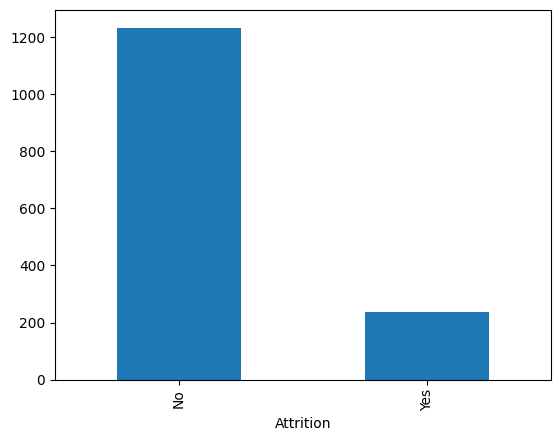

In [162]:
newData["Attrition"].value_counts().plot(kind="bar")

#### Department Count

<Axes: xlabel='Department'>

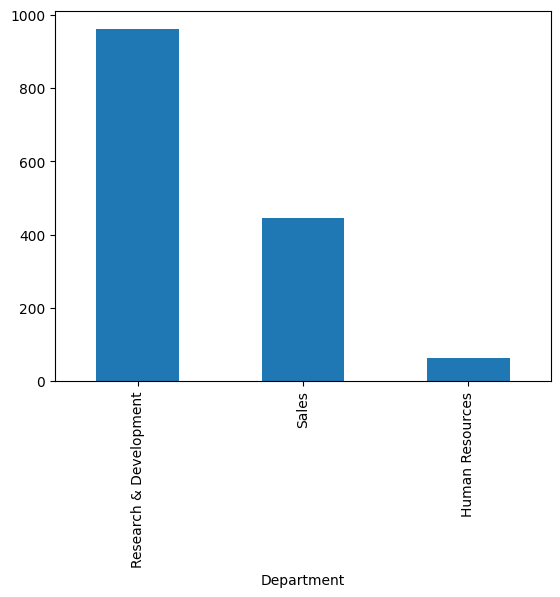

In [164]:
newData["Department"].value_counts().plot(kind="bar")

#### Average Salary by Department

<Axes: xlabel='Department'>

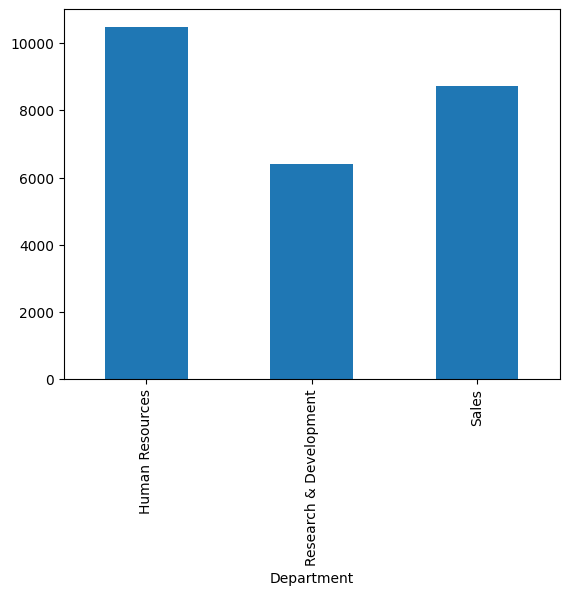

In [165]:
department_salary = data.groupby("Department")["MonthlyIncome"].mean()

department_salary.plot(kind="bar")

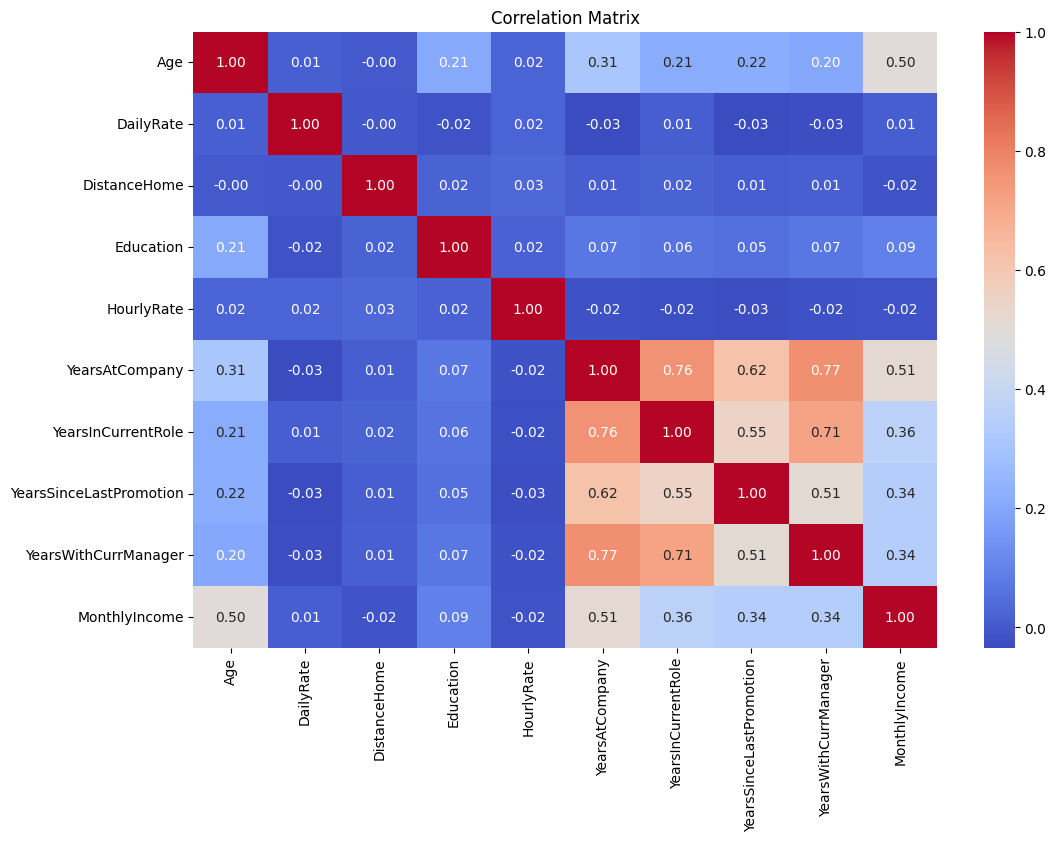

In [ ]:

numeric_cols = newData.select_dtypes(include='number')
plt.figure(figsize=(12,8))
sns.heatmap(numeric_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()